# Cluster Sweep Analysis — How does k affect cluster-local DQN performance?

Trains cluster-local DQN agents for **k ∈ {1, 2, 5, 10, 15, 20, 25, 30}** and evaluates them on the
**same 10 fixed households** across all k values.

The 10 eval users are the centroid-nearest users from the 10 largest clusters in the k=30 solution,
ensuring they represent maximally diverse consumption profiles.

**Key efficiency:** MILP and no-battery baselines are computed once (k-independent).
Only clusters that contain at least one eval user are trained for each k.

**Comparison plots:**
- DQN improvement % over no-battery baseline vs k
- Fraction of theoretical (MILP) gain vs k
- Per-user detail across all k values

## Cell 1 — Imports & device

In [1]:
import os
import sys
import importlib
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pulp

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.preprocessing import RobustScaler

# Add project root to path so imports resolve whether running from repo root
# or from inside cluster_sweep_analysis/
NOTEBOOK_DIR = os.path.abspath('')
if os.path.basename(NOTEBOOK_DIR) == 'cluster_sweep_analysis':
    PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
else:
    PROJECT_ROOT = NOTEBOOK_DIR   # already at root

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import Environment as environment_module
importlib.reload(environment_module)
HouseholdEnvironment = environment_module.HouseholdEnvironment

from Basic_Functions import (
    calculate_interval_price,
    run_milp_benchmark,
    milp_total_cost,
)

if T.cuda.is_available():
    device = T.device('cuda')
    print(f'NVIDIA CUDA: {T.cuda.get_device_name(0)}')
elif T.backends.mps.is_available():
    device = T.device('mps')
    print('Apple Silicon MPS')
else:
    device = T.device('cpu')
    print('CPU')

print(f'Project root: {PROJECT_ROOT}')

Apple Silicon MPS
Project root: /Users/tomaz/Documents/Andraz/Household-RL


## Cell 2 — Configuration

In [2]:
# ── Sweep settings ──────────────────────────────────────────
# k values to evaluate. Files must exist in clustering_results/.
K_VALUES = [1, 2, 5, 10, 15, 20, 25, 30]

# 10 fixed eval users: centroid-nearest from the 10 largest clusters in k=30.
# These span diverse consumption profiles and stay constant across all k.
FIXED_EVAL_UIDS = [5, 21, 27, 29, 65, 66, 67, 172, 179, 204]

CLUSTER_DIR = os.path.join(PROJECT_ROOT, 'clustering_results')
DATA_DIR    = os.path.join(PROJECT_ROOT, 'Datasorted by user')

# ── Physics (30-min step) ───────────────────────────────────
BASE_STEP_MINUTES    = 15.0
DATASET_STEP_MINUTES = 30.0
step_scale           = DATASET_STEP_MINUTES / BASE_STEP_MINUTES

KorakovNaDan     = int(round(1440 / DATASET_STEP_MINUTES))  # 48
BatKapaciteta    = 20.0
BatUcinkovitost  = 0.95
BatMaxPolnjenje  = 1.5 * step_scale
BatMaxPraznjenje = 1.5 * step_scale
faktorN1, faktorN2, faktorN3 = 0, 0, 1

# ── DQN hyper-parameters ────────────────────────────────────
fc1_dims, fc2_dims, fc3_dims, fc4_dims = 256, 128, 64, 32
lr             = 0.001
gamma          = 0.99
epsilon_start  = 1.0
epsilon_end    = 0.01
epsilon_decay  = 4e-5 / 4
batch_size     = 48
replace_target = KorakovNaDan * 7   # 336 steps
weight_decay   = 1e-4

# ── Training schedule ───────────────────────────────────────
# Same as cluster_model_DQN.ipynb. Reduce for quick testing.
N_ROUNDS           = 40 * 4   # 160
EPISODES_PER_ROUND = 10
EPISODE_STEPS      = KorakovNaDan * 7   # 336 = 1 week

print(f'k values to sweep: {K_VALUES}')
print(f'Fixed eval users : {FIXED_EVAL_UIDS}')
print(f'Training         : {N_ROUNDS} rounds × {EPISODES_PER_ROUND} eps × {EPISODE_STEPS} steps')

k values to sweep: [1, 2, 5, 10, 15, 20, 25, 30]
Fixed eval users : [5, 21, 27, 29, 65, 66, 67, 172, 179, 204]
Training         : 160 rounds × 10 eps × 336 steps


## Cell 3 — Load all 300 datasets

In [3]:
def load_ausgrid(uid):
    path = os.path.join(DATA_DIR, f'Ausgrid {uid}.csv')
    df = pd.read_csv(path)
    df.index = pd.to_datetime(df['Timestamp_UTC'], format='ISO8601')
    df = df.drop(columns=['Timestamp_UTC'])
    return df

print('Loading 300 datasets...')
train_dfs = {}
test_dfs  = {}

for uid in range(1, 301):
    df    = load_ausgrid(uid)
    split = int(len(df) * 2 / 3)
    train_dfs[uid] = df.iloc[:split].copy()
    test_dfs[uid]  = df.iloc[split:].copy()

print(f'Loaded. Train rows: {len(train_dfs[1])}  Test rows: {len(test_dfs[1])}')

Loading 300 datasets...
Loaded. Train rows: 35072  Test rows: 17536


## Cell 4 — Normalization & environment helpers

In [4]:
SHARED_COLS = ['Energy_Generation', 'Energy_Consumption']

def normalize_electricity_prices(data, fit=False, params=None):
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)
    log_data     = np.log1p(np.maximum(data, 0))
    log_lower    = np.log1p(max(0, lower_threshold))
    log_upper    = np.log1p(max(0, upper_threshold))
    clipped      = np.clip(log_data, log_lower, log_upper)

    if fit:
        scaler     = RobustScaler()
        normalized = scaler.fit_transform(clipped)
        return normalized, outlier_flag, {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        return params['scaler'].transform(clipped), outlier_flag, params


# Fit SMP scaler once — SMP is identical across all users
_, _, PRICE_NORM_PARAMS = normalize_electricity_prices(train_dfs[1]['SMP'].values, fit=True)
print('SMP scaler fitted (shared).')


def apply_normalization(df, energy_scaler):
    df_n = df.copy()
    for col in SHARED_COLS:
        df_n[col] = energy_scaler.transform(df[col].values.reshape(-1, 1)).flatten()
    smp_norm, smp_flag, _ = normalize_electricity_prices(
        df['SMP'].values, fit=False, params=PRICE_NORM_PARAMS)
    df_n['SMP'] = smp_norm.flatten()
    df_n['SMP_OutlierFlag'] = smp_flag.flatten()
    return df_n


def fit_cluster_scaler(train_uids):
    """Fit a RobustScaler on the energy columns of the training split for given uids."""
    combined = np.concatenate([
        train_dfs[uid][SHARED_COLS].values.flatten()
        for uid in train_uids
    ]).reshape(-1, 1)
    return RobustScaler().fit(combined)


def make_env(uid, norm_train_df, norm_test_df, split='train', episode_length=None):
    """Create a HouseholdEnvironment with pre-normalised data."""
    if split == 'train':
        data, data_n = train_dfs[uid], norm_train_df
        reset_mode   = 'random'
        ep_len       = episode_length if episode_length is not None else EPISODE_STEPS
    else:
        data, data_n = test_dfs[uid], norm_test_df
        reset_mode   = 'deterministic'
        ep_len       = episode_length if episode_length is not None else len(data) - 1

    return HouseholdEnvironment(
        dataset            = data,
        dataset_norm       = data_n,
        observation_mode   = 'sliding_window',
        reset_mode         = reset_mode,
        episode_length     = ep_len,
        korakov_na_dan     = KorakovNaDan,
        bat_kapaciteta     = BatKapaciteta,
        bat_ucinkovitost   = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )

# Determine state dimension from a sample env
_tmp_scaler = fit_cluster_scaler([1])
_tmp_norm   = apply_normalization(train_dfs[1], _tmp_scaler)
_tmp_env    = make_env(1, _tmp_norm, _tmp_norm, split='train')
STATE_DIM   = int(_tmp_env.observation_space.shape[0])
NETWORK_DIMS = [STATE_DIM, fc1_dims, fc2_dims, fc3_dims, fc4_dims, 5]
print(f'State dim: {STATE_DIM}   Network: {NETWORK_DIMS}')

SMP scaler fitted (shared).
State dim: 25   Network: [25, 256, 128, 64, 32, 5]


## Cell 5 — DQN agent (identical to cluster_model_DQN.ipynb)

In [5]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super().__init__()
        self.layer_dims = list(layer_dims)
        self.layers = nn.ModuleList([
            nn.Linear(in_d, out_d)
            for in_d, out_d in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])
        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.loss = nn.SmoothL1Loss(beta=1.0)
        self.device = T.device('cuda' if T.cuda.is_available() else
                               'mps'  if T.backends.mps.is_available() else 'cpu')
        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(self, gamma, epsilon, lr, state_shape, network_dims,
                 batch_size, replace_target=336, max_mem_size=1_000_000,
                 eps_end=0.05, eps_dec=4e-5, weight_decay=1e-4, tau=0.005):
        self.gamma          = gamma
        self.epsilon        = epsilon
        self.eps_min        = eps_end
        self.eps_dec        = eps_dec
        self.lr             = lr
        self.batch_size     = batch_size
        self.mem_size       = max_mem_size
        self.mem_cntr       = 0
        self.iter_cntr      = 0
        self.replace_target = replace_target
        self.tau            = float(tau)
        self.state_shape    = list(state_shape)
        self.network_dims   = list(network_dims)
        self.n_actions      = self.network_dims[-1]
        self.action_space   = list(range(self.n_actions))
        self.start_learning_after = int(4 * batch_size)

        self.Q_eval   = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        self.state_memory     = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory    = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory    = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory  = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        idx = self.mem_cntr % self.mem_size
        self.state_memory[idx]     = state
        self.new_state_memory[idx] = state_
        self.reward_memory[idx]    = reward
        self.action_memory[idx]    = action
        self.terminal_memory[idx]  = terminal
        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state   = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)
            actions = self.Q_eval.forward(state)
            return int(T.argmax(actions).item())
        return np.random.choice(self.action_space)

    def _soft_update_target(self):
        with T.no_grad():
            for tp, ep in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                tp.data.mul_(1.0 - self.tau).add_(self.tau * ep.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return
        max_mem = min(self.mem_cntr, self.mem_size)
        if max_mem < self.batch_size:
            return

        batch       = np.random.choice(max_mem, self.batch_size, replace=False)
        batch_index = np.arange(self.batch_size, dtype=np.int32)

        dev = self.Q_eval.device
        s   = T.tensor(self.state_memory[batch],     dtype=T.float32, device=dev)
        s_  = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=dev)
        a   = T.tensor(self.action_memory[batch],    dtype=T.long,    device=dev)
        r   = T.tensor(self.reward_memory[batch],    dtype=T.float32, device=dev)
        t   = T.tensor(self.terminal_memory[batch],  dtype=T.float32, device=dev)

        q_eval = self.Q_eval(s)[batch_index, a]
        with T.no_grad():
            next_a   = self.Q_eval(s_).argmax(dim=1, keepdim=True)
            q_next   = self.Q_target(s_).gather(1, next_a).squeeze(1)
            q_target = r + self.gamma * q_next * (1 - t)

        loss = self.Q_eval.loss(q_eval, q_target).to(dev)
        self.Q_eval.optimizer.zero_grad()
        loss.backward()
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)
        self.Q_eval.optimizer.step()

        self.iter_cntr += 1
        self.epsilon = max(self.epsilon - self.eps_dec, self.eps_min)

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())


def make_agent():
    return AgentDQN(
        gamma          = gamma,
        epsilon        = epsilon_start,
        lr             = lr,
        state_shape    = [STATE_DIM],
        network_dims   = NETWORK_DIMS,
        batch_size     = batch_size,
        replace_target = replace_target,
        eps_end        = epsilon_end,
        eps_dec        = epsilon_decay,
        weight_decay   = weight_decay,
    )

print('DQN classes defined.')

DQN classes defined.


## Cell 6 — Evaluation functions

In [6]:
def evaluate_dqn(agent, uid, norm_test_df):
    """Greedy DQN rollout on the test split. Returns total cost (AUD)."""
    env = make_env(uid, None, norm_test_df, split='test')
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})

    saved_eps     = agent.epsilon
    agent.epsilon = 0.0
    last_info     = {}

    for _ in range(len(test_dfs[uid]) - 1):
        action = agent.choose_action(obs)
        obs, _, terminated, truncated, info = env.step(action)
        last_info = info
        if terminated or truncated:
            break

    agent.epsilon = saved_eps
    return float(last_info.get('cumulative_payment', 0.0))


def no_battery_baseline(uid):
    """Always idle, no battery — k-independent. Returns total cost (AUD)."""
    # Uses a dummy normalization (no-battery baseline ignores observations)
    dummy_scaler = fit_cluster_scaler([uid])
    dummy_norm   = apply_normalization(test_dfs[uid], dummy_scaler)

    env = HouseholdEnvironment(
        dataset            = test_dfs[uid],
        dataset_norm       = dummy_norm,
        observation_mode   = 'sliding_window',
        reset_mode         = 'deterministic',
        episode_length     = len(test_dfs[uid]) - 1,
        korakov_na_dan     = KorakovNaDan,
        bat_kapaciteta     = 0,
        bat_ucinkovitost   = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})
    last_info = {}
    for _ in range(len(test_dfs[uid]) - 1):
        obs, _, terminated, truncated, last_info = env.step(4)
        if terminated or truncated:
            break
    return float(last_info.get('cumulative_payment', 0.0))


def run_milp(uid):
    """Perfect-foresight MILP — k-independent. Returns total cost (AUD).

    Thin wrapper around the shared Basic_Functions.run_milp_benchmark
    implementation (same formulation as all the other notebooks).
    """
    dummy_scaler = fit_cluster_scaler([uid])
    dummy_norm   = apply_normalization(test_dfs[uid], dummy_scaler)

    env = HouseholdEnvironment(
        dataset            = test_dfs[uid],
        dataset_norm       = dummy_norm,
        observation_mode   = 'sliding_window',
        reset_mode         = 'deterministic',
        episode_length     = len(test_dfs[uid]) - 1,
        korakov_na_dan     = KorakovNaDan,
        bat_kapaciteta     = BatKapaciteta,
        bat_ucinkovitost   = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )
    return milp_total_cost(env, problem_name=f'MG_U{uid}')


print('Evaluation functions defined.')

Evaluation functions defined.


## Cell 7 — Pre-compute k-independent baselines (run once)

In [7]:
print('Pre-computing no-battery baselines and MILP optima for all eval users...')
print('(These are k-independent — computed once and reused across all k values.)\n')

baseline_costs = {}
milp_costs     = {}

for uid in FIXED_EVAL_UIDS:
    base = no_battery_baseline(uid)
    milp = run_milp(uid)
    baseline_costs[uid] = base
    milp_costs[uid]     = milp
    print(f'  User {uid:3d}: baseline={base:8.2f} AUD   MILP={milp:8.2f} AUD')

print('\nDone.')

Pre-computing no-battery baselines and MILP optima for all eval users...
(These are k-independent — computed once and reused across all k values.)

  User   5: baseline= 1119.50 AUD   MILP=  888.11 AUD
  User  21: baseline= 1882.85 AUD   MILP= 1231.53 AUD
  User  27: baseline= 1323.00 AUD   MILP=  979.70 AUD
  User  29: baseline= 1265.11 AUD   MILP=  880.64 AUD
  User  65: baseline= 1367.03 AUD   MILP=  986.16 AUD
  User  66: baseline= 1000.19 AUD   MILP=  789.58 AUD
  User  67: baseline= 1265.49 AUD   MILP=  849.92 AUD
  User 172: baseline= 1187.68 AUD   MILP=  898.08 AUD
  User 179: baseline= 1183.54 AUD   MILP=  900.78 AUD
  User 204: baseline= 1167.46 AUD   MILP=  867.82 AUD

Done.


## Cell 8 — Main sweep loop

For each k:
1. Load cluster assignments from `clustering_results/user_ids_sorted_by_cluster_{k}.csv`
2. Determine which cluster each eval user belongs to
3. Train one DQN per **distinct cluster** that contains eval users (no redundant training)
4. Evaluate all eval users using their respective cluster's DQN

In [8]:
import time

def train_cluster_dqn(agent, all_uids, norm_train_dfs, rng_,
                      n_rounds=N_ROUNDS, episodes_per_round=EPISODES_PER_ROUND):
    """Train agent on the given cluster of users. Returns per-round reward list."""
    round_rewards = []
    for round_i in range(n_rounds):
        sampled = rng_.choice(all_uids, episodes_per_round, replace=True)
        round_r = 0.0
        n_done  = 0

        for uid in sampled:
            env = make_env(uid, norm_train_dfs[uid], None, split='train',
                           episode_length=EPISODE_STEPS)
            obs, _ = env.reset()
            ep_r   = 0.0
            for _ in range(EPISODE_STEPS):
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)
                agent.store_transition(obs, action, reward, next_obs, done)
                agent.learn()
                obs    = next_obs
                ep_r  += reward
                if done:
                    break
            round_r += ep_r
            n_done  += 1

        avg = round_r / max(n_done, 1)
        round_rewards.append(avg)

        if (round_i + 1) % 20 == 0 or round_i == 0:
            print(f'      Round {round_i+1:3d}/{n_rounds}  avg={avg:7.2f}  ε={agent.epsilon:.4f}')

    return round_rewards


rng = np.random.default_rng(42)
sweep_results  = []   # list of dicts, one per (k, uid)
sweep_rewards  = {}   # (k, cluster_id) -> list of round rewards for later plotting

total_clusters_trained = 0

for k in K_VALUES:
    t_k_start = time.time()
    print(f'\n{"="*70}')
    print(f'  k = {k} clusters')
    print(f'{"="*70}')

    # ── Load cluster assignments ──────────────────────────────
    csv_path   = os.path.join(CLUSTER_DIR, f'user_ids_sorted_by_cluster_{k}.csv')
    df_clust   = pd.read_csv(csv_path)
    df_clust['uid'] = df_clust['user_id'].str.extract(r'(\d+)').astype(int)

    # ── Map eval users to their cluster at this k ─────────────
    eval_uid_to_cid = {
        uid: int(df_clust.loc[df_clust['uid'] == uid, 'cluster'].values[0])
        for uid in FIXED_EVAL_UIDS
    }

    # ── Group eval users by cluster ───────────────────────────
    cid_to_eval_uids = defaultdict(list)
    for uid, cid in eval_uid_to_cid.items():
        cid_to_eval_uids[cid].append(uid)

    print(f'  Eval users span {len(cid_to_eval_uids)} distinct cluster(s).')

    # ── Train one DQN per distinct cluster ────────────────────
    cluster_agents_k  = {}    # cid -> trained agent
    cluster_norm_test = {}    # cid -> {uid: norm_test_df}

    for cid, eval_uids_in_c in sorted(cid_to_eval_uids.items()):
        all_uids_in_c = df_clust.loc[df_clust['cluster'] == cid, 'uid'].tolist()
        n_users = len(all_uids_in_c)

        print(f'\n  ── Cluster {cid} ({n_users} users, '
              f'eval: {eval_uids_in_c}) ──')

        # Per-cluster normalization
        scaler = fit_cluster_scaler(all_uids_in_c)
        norm_train = {uid: apply_normalization(train_dfs[uid], scaler)
                      for uid in all_uids_in_c}
        norm_test  = {uid: apply_normalization(test_dfs[uid],  scaler)
                      for uid in all_uids_in_c}

        # Train
        agent   = make_agent()
        rewards = train_cluster_dqn(agent, all_uids_in_c, norm_train, rng)
        cluster_agents_k[cid]  = agent
        cluster_norm_test[cid] = norm_test
        sweep_rewards[(k, cid)] = rewards
        total_clusters_trained += 1

        print(f'      Final ε={agent.epsilon:.4f}')

    # ── Evaluate each eval user ───────────────────────────────
    for uid in FIXED_EVAL_UIDS:
        cid       = eval_uid_to_cid[uid]
        agent     = cluster_agents_k[cid]
        norm_test = cluster_norm_test[cid][uid]
        dqn_cost  = evaluate_dqn(agent, uid, norm_test)
        base_cost = baseline_costs[uid]
        milp_cost = milp_costs[uid]

        imp_dqn   = (base_cost - dqn_cost)  / abs(base_cost)          * 100
        imp_milp  = (base_cost - milp_cost) / abs(base_cost)          * 100
        gap_milp  = (dqn_cost  - milp_cost) / abs(milp_cost)          * 100
        frac_theor = (base_cost - dqn_cost) / (base_cost - milp_cost) * 100

        sweep_results.append({
            'k':             k,
            'uid':           uid,
            'cluster_id':    cid,
            'n_cluster':     len(df_clust[df_clust['cluster'] == cid]),
            'dqn_cost':      dqn_cost,
            'baseline_cost': base_cost,
            'milp_cost':     milp_cost,
            'imp_dqn_%':     round(imp_dqn,    1),
            'imp_milp_%':    round(imp_milp,   1),
            'gap_milp_%':    round(gap_milp,   1),
            'frac_theor_%':  round(frac_theor, 1),
        })

    elapsed_k = time.time() - t_k_start
    print(f'\n  k={k} done in {elapsed_k/60:.1f} min.')

df_sweep = pd.DataFrame(sweep_results)
print(f'\n{"="*70}')
print(f'Sweep complete. Total cluster DQNs trained: {total_clusters_trained}')
print(f'Result rows: {len(df_sweep)}')


  k = 1 clusters
  Eval users span 1 distinct cluster(s).

  ── Cluster 0 (300 users, eval: [5, 21, 27, 29, 65, 66, 67, 172, 179, 204]) ──
      Round   1/160  avg= -27.88  ε=0.9684
      Round  20/160  avg= -14.24  ε=0.3319
      Round  40/160  avg=  -4.25  ε=0.0100
      Round  60/160  avg=  -3.78  ε=0.0100
      Round  80/160  avg=  -4.92  ε=0.0100
      Round 100/160  avg=  -3.89  ε=0.0100
      Round 120/160  avg=  -3.34  ε=0.0100
      Round 140/160  avg=  -3.71  ε=0.0100
      Round 160/160  avg=  -3.68  ε=0.0100
      Final ε=0.0100

  k=1 done in 50.8 min.

  k = 2 clusters
  Eval users span 2 distinct cluster(s).

  ── Cluster 0 (117 users, eval: [21, 67]) ──
      Round   1/160  avg= -32.62  ε=0.9684
      Round  20/160  avg= -13.05  ε=0.3319
      Round  40/160  avg=  -6.47  ε=0.0100
      Round  60/160  avg=  -5.48  ε=0.0100
      Round  80/160  avg=  -4.39  ε=0.0100
      Round 100/160  avg=  -3.86  ε=0.0100
      Round 120/160  avg=  -4.79  ε=0.0100
      Round 140/160 

## Cell 9 — Results table

In [9]:
# Pivot: rows = k, cols = uid, values = imp_dqn_%
pivot_imp  = df_sweep.pivot(index='k', columns='uid', values='imp_dqn_%')
pivot_frac = df_sweep.pivot(index='k', columns='uid', values='frac_theor_%')

# Per-k averages
df_avg = df_sweep.groupby('k').agg(
    avg_imp_dqn   = ('imp_dqn_%',    'mean'),
    avg_frac_theor= ('frac_theor_%', 'mean'),
    avg_gap_milp  = ('gap_milp_%',   'mean'),
).round(2)

print('═' * 100)
print('AVERAGE METRICS BY k')
print('═' * 100)
print(df_avg.to_string())

print('\n' + '═' * 100)
print('DQN IMPROVEMENT % — per eval user, per k')
print('═' * 100)
print(pivot_imp.to_string())

print('\n' + '═' * 100)
print('FRACTION OF THEORETICAL GAIN % — per eval user, per k')
print('═' * 100)
print(pivot_frac.to_string())

════════════════════════════════════════════════════════════════════════════════════════════════════
AVERAGE METRICS BY k
════════════════════════════════════════════════════════════════════════════════════════════════════
    avg_imp_dqn  avg_frac_theor  avg_gap_milp
k                                            
1         15.37           57.49         15.73
2          8.87           33.45         24.77
5          9.81           38.08         23.63
10         9.79           35.36         23.28
15        12.94           47.29         18.91
20        14.62           54.63         16.76
25        15.91           59.33         14.91
30         9.98           37.25         23.19

════════════════════════════════════════════════════════════════════════════════════════════════════
DQN IMPROVEMENT % — per eval user, per k
════════════════════════════════════════════════════════════════════════════════════════════════════
uid   5     21    27    29    65    66    67    172   179   204
k        

## Cell 10 — Comparison plots

/var/folders/b7/qjrjh1px26n77cqksgr8kf0m0000gq/T/ipykernel_58391/798632635.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(FIXED_EVAL_UIDS))


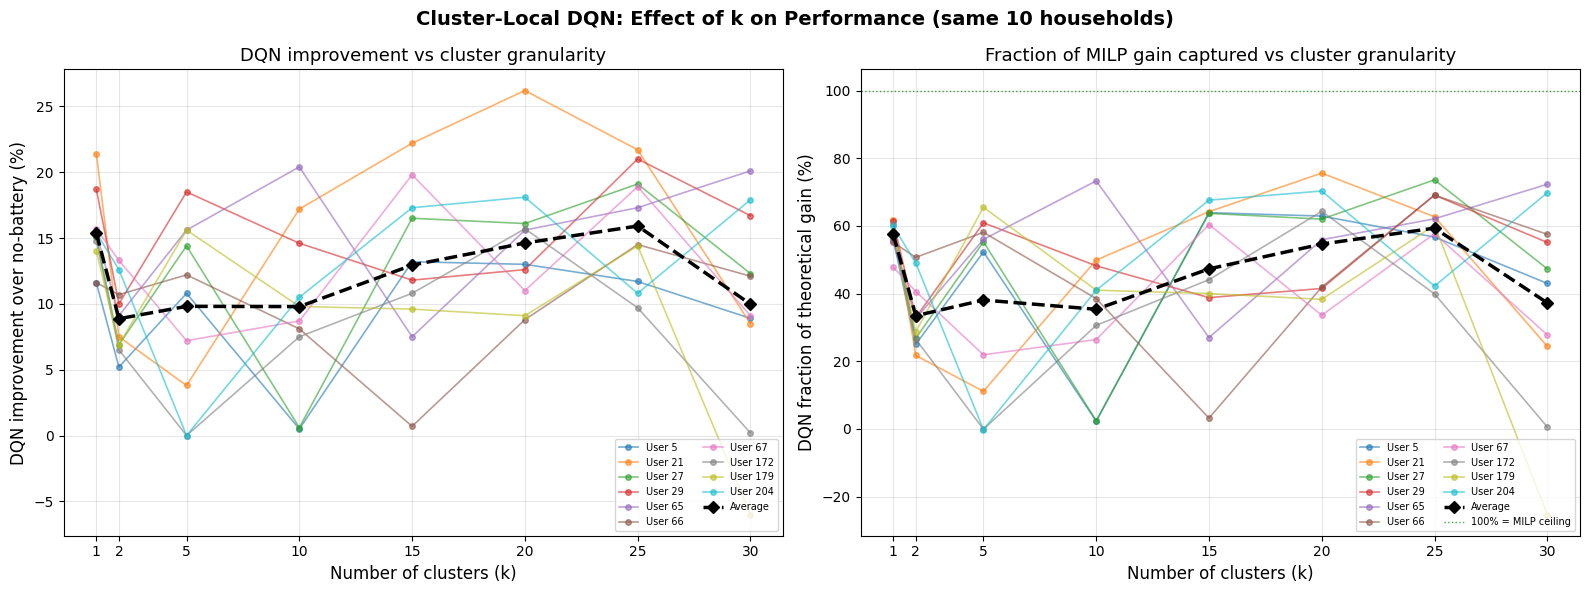

Saved: sweep_improvement_vs_k.png


In [10]:
# ── Colour palette: one colour per eval user ─────────────────
cmap   = plt.cm.get_cmap('tab10', len(FIXED_EVAL_UIDS))
uid_colors = {uid: cmap(i) for i, uid in enumerate(FIXED_EVAL_UIDS)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: DQN improvement % vs k ───────────────────────────
ax = axes[0]
for uid in FIXED_EVAL_UIDS:
    sub = df_sweep[df_sweep['uid'] == uid].sort_values('k')
    ax.plot(sub['k'], sub['imp_dqn_%'],
            color=uid_colors[uid], linewidth=1.2, alpha=0.6,
            marker='o', markersize=4, label=f'User {uid}')

# Bold average line
ax.plot(df_avg.index, df_avg['avg_imp_dqn'],
        color='black', linewidth=2.5, linestyle='--',
        marker='D', markersize=6, label='Average')

ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('DQN improvement over no-battery (%)', fontsize=12)
ax.set_title('DQN improvement vs cluster granularity', fontsize=13)
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='lower right')

# ── Plot 2: Fraction of theoretical gain vs k ─────────────────
ax = axes[1]
for uid in FIXED_EVAL_UIDS:
    sub = df_sweep[df_sweep['uid'] == uid].sort_values('k')
    ax.plot(sub['k'], sub['frac_theor_%'],
            color=uid_colors[uid], linewidth=1.2, alpha=0.6,
            marker='o', markersize=4, label=f'User {uid}')

ax.plot(df_avg.index, df_avg['avg_frac_theor'],
        color='black', linewidth=2.5, linestyle='--',
        marker='D', markersize=6, label='Average')

ax.axhline(100, color='green', linewidth=1.0, linestyle=':', alpha=0.7,
           label='100% = MILP ceiling')

ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('DQN fraction of theoretical gain (%)', fontsize=12)
ax.set_title('Fraction of MILP gain captured vs cluster granularity', fontsize=13)
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='lower right')

fig.suptitle('Cluster-Local DQN: Effect of k on Performance (same 10 households)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(NOTEBOOK_DIR, 'sweep_improvement_vs_k.png'), dpi=150)
plt.show()
print('Saved: sweep_improvement_vs_k.png')

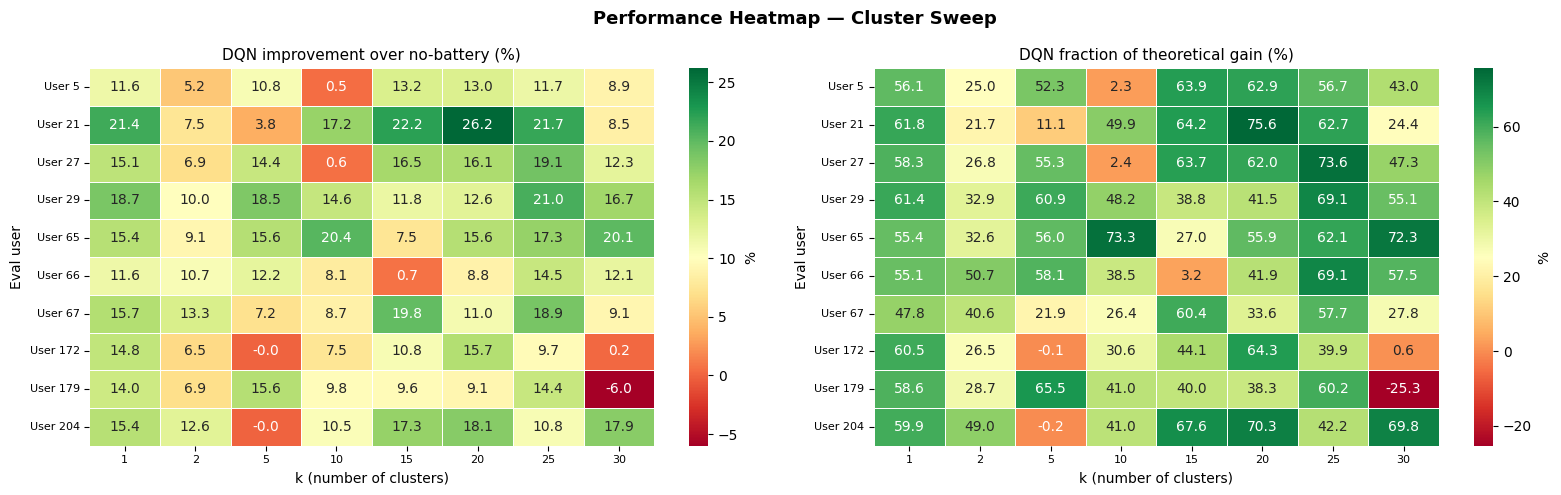

Saved: sweep_heatmap.png


In [11]:
# ── Heatmap: rows = eval users, cols = k, value = DQN improvement % ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (col, title) in zip(axes, [
    ('imp_dqn_%',   'DQN improvement over no-battery (%)'),
    ('frac_theor_%', 'DQN fraction of theoretical gain (%)'),
]):
    piv = df_sweep.pivot(index='uid', columns='k', values=col)
    piv.index = [f'User {u}' for u in piv.index]

    sns.heatmap(
        piv, ax=ax,
        cmap='RdYlGn',
        annot=True, fmt='.1f',
        linewidths=0.5,
        cbar_kws={'label': '%'},
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('k (number of clusters)', fontsize=10)
    ax.set_ylabel('Eval user', fontsize=10)
    ax.tick_params(labelsize=8)

fig.suptitle('Performance Heatmap — Cluster Sweep', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(NOTEBOOK_DIR, 'sweep_heatmap.png'), dpi=150)
plt.show()
print('Saved: sweep_heatmap.png')

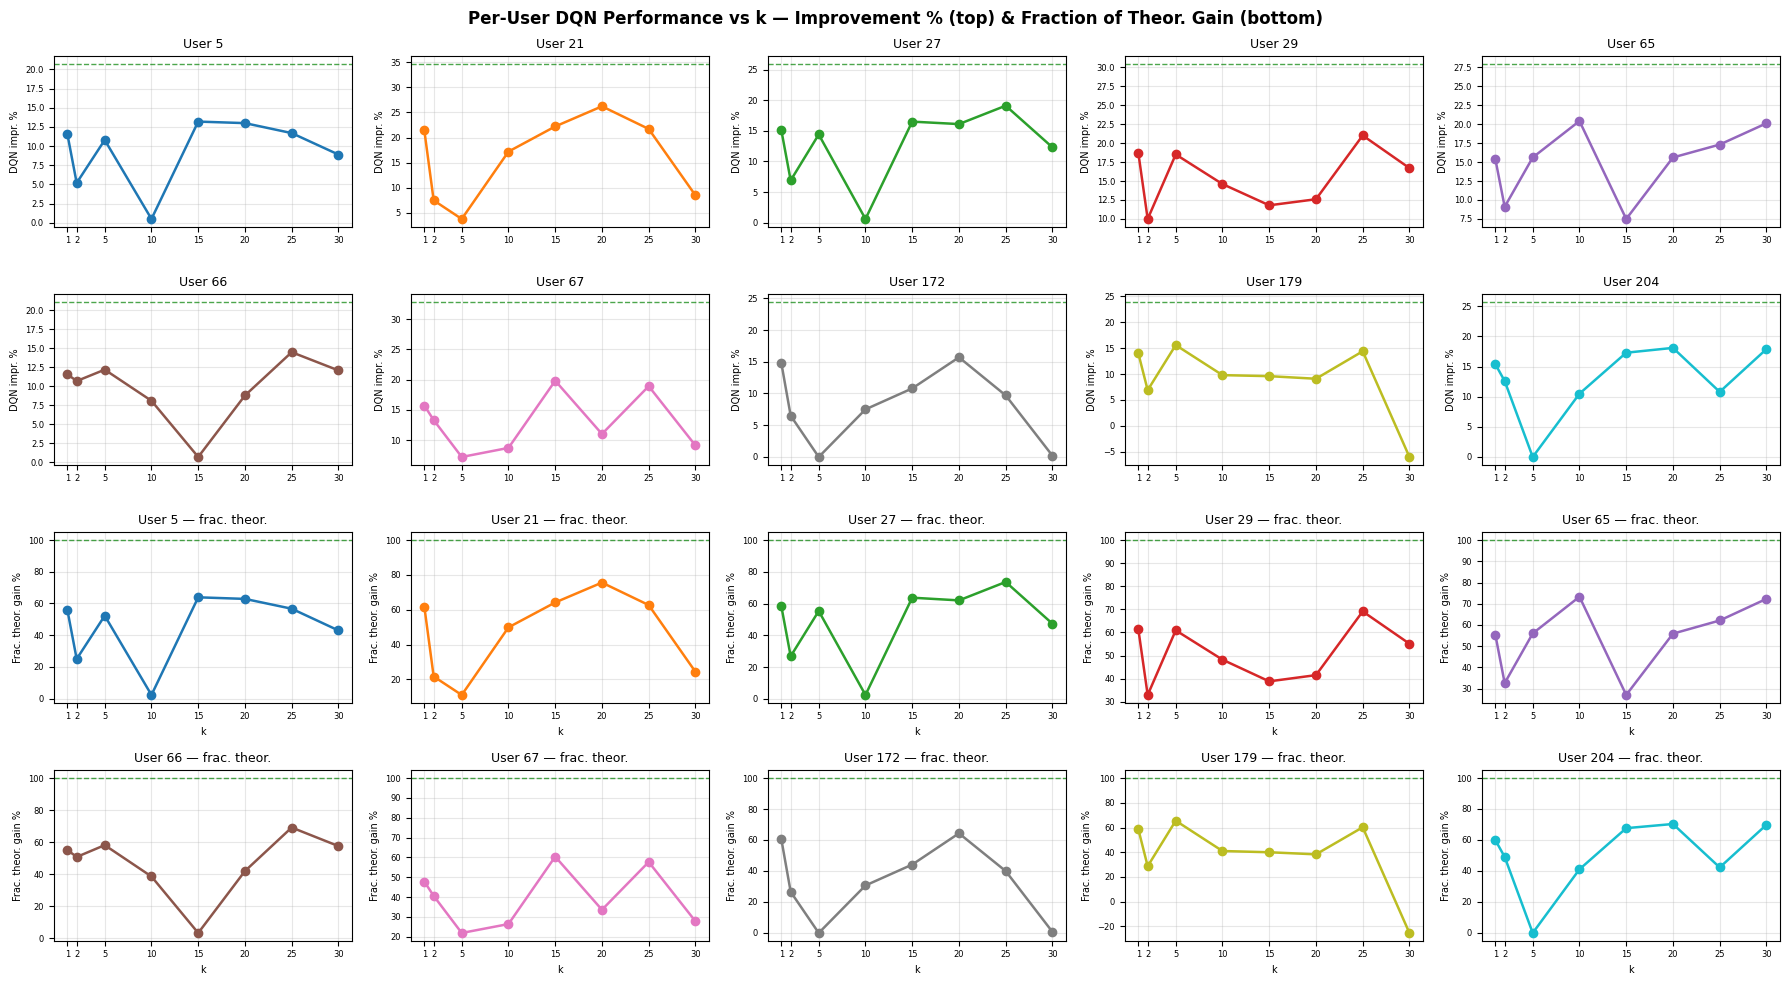

Saved: sweep_per_user.png


In [12]:
# ── Per-user line plot — improvement and fraction side by side ──
n_users = len(FIXED_EVAL_UIDS)
n_cols  = 5
n_rows  = (n_users + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows * 2, n_cols, figsize=(18, 5 * n_rows))
# row 0..n_rows-1: improvement %, row n_rows..: fraction of theor

for i, uid in enumerate(FIXED_EVAL_UIDS):
    row_imp  = i // n_cols
    row_frac = row_imp + n_rows
    col      = i % n_cols
    sub      = df_sweep[df_sweep['uid'] == uid].sort_values('k')

    ax = axes[row_imp][col]
    ax.plot(sub['k'], sub['imp_dqn_%'], color=uid_colors[uid],
            marker='o', linewidth=1.8)
    ax.axhline(sub['imp_milp_%'].iloc[0], color='green',
               linewidth=1, linestyle='--', alpha=0.7, label='MILP impr.')
    ax.set_title(f'User {uid}', fontsize=9)
    ax.set_ylabel('DQN impr. %', fontsize=7)
    ax.set_xticks(K_VALUES)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

    ax = axes[row_frac][col]
    ax.plot(sub['k'], sub['frac_theor_%'], color=uid_colors[uid],
            marker='o', linewidth=1.8)
    ax.axhline(100, color='green', linewidth=1, linestyle='--',
               alpha=0.7, label='100% ceiling')
    ax.set_title(f'User {uid} — frac. theor.', fontsize=9)
    ax.set_ylabel('Frac. theor. gain %', fontsize=7)
    ax.set_xlabel('k', fontsize=7)
    ax.set_xticks(K_VALUES)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(len(FIXED_EVAL_UIDS), n_rows * n_cols):
    axes[j // n_cols][j % n_cols].set_visible(False)
    axes[j // n_cols + n_rows][j % n_cols].set_visible(False)

fig.suptitle('Per-User DQN Performance vs k — Improvement % (top) & Fraction of Theor. Gain (bottom)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(NOTEBOOK_DIR, 'sweep_per_user.png'), dpi=150)
plt.show()
print('Saved: sweep_per_user.png')

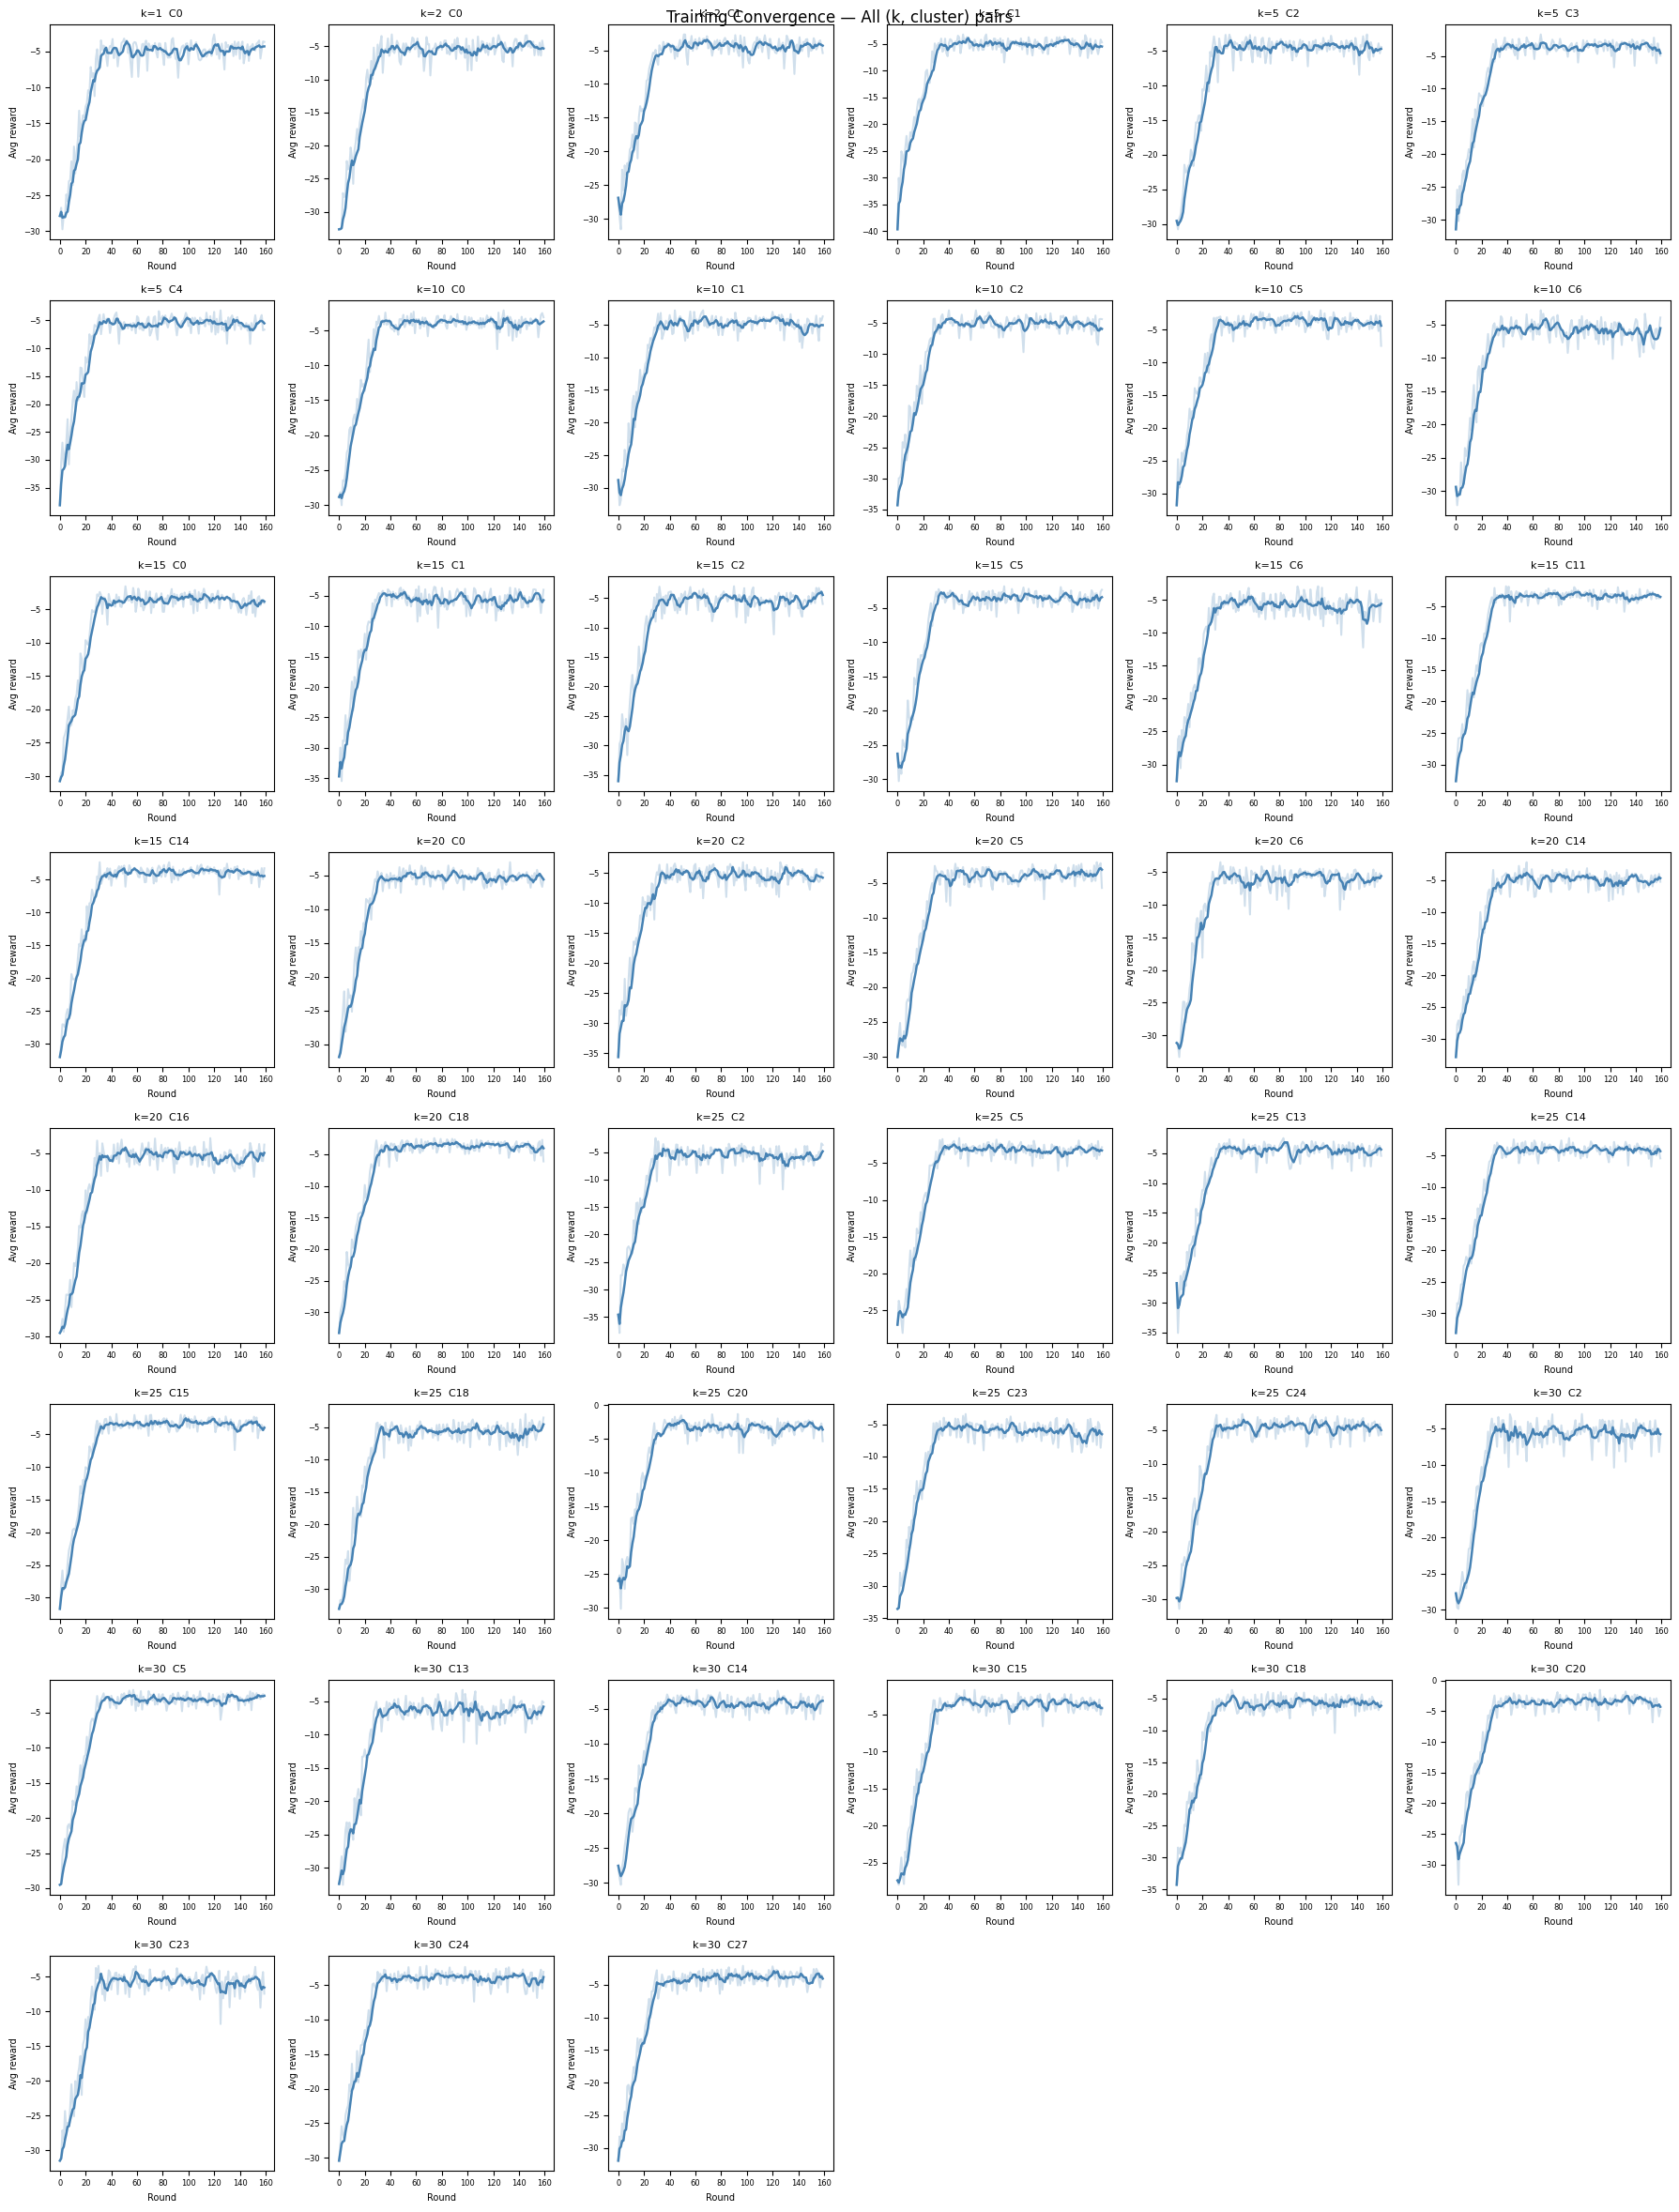

Saved: sweep_training_curves.png


In [13]:
# ── Training curve grid: one subplot per (k, cluster) ────────
window   = 5
n_models = len(sweep_rewards)
n_cols_r = 6
n_rows_r = (n_models + n_cols_r - 1) // n_cols_r

fig, axes = plt.subplots(n_rows_r, n_cols_r,
                         figsize=(18, 3 * n_rows_r), squeeze=False)
axes_flat = axes.flatten()

for i, ((k, cid), rewards) in enumerate(sorted(sweep_rewards.items())):
    ax    = axes_flat[i]
    trend = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
    ax.plot(rewards, alpha=0.25, color='steelblue')
    ax.plot(trend,   linewidth=1.8, color='steelblue')
    ax.set_title(f'k={k}  C{cid}', fontsize=8)
    ax.set_xlabel('Round', fontsize=7)
    ax.set_ylabel('Avg reward', fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Training Convergence — All (k, cluster) pairs', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(NOTEBOOK_DIR, 'sweep_training_curves.png'), dpi=150)
plt.show()
print('Saved: sweep_training_curves.png')

In [14]:
# ── Save numeric results to CSV ───────────────────────────────
out_csv = os.path.join(NOTEBOOK_DIR, 'sweep_results.csv')
df_sweep.to_csv(out_csv, index=False)
print(f'Results saved to {out_csv}')
print('\nFinal average table:')
print(df_avg.to_string())

Results saved to /Users/tomaz/Documents/Andraz/Household-RL/cluster_sweep_analysis/sweep_results.csv

Final average table:
    avg_imp_dqn  avg_frac_theor  avg_gap_milp
k                                            
1         15.37           57.49         15.73
2          8.87           33.45         24.77
5          9.81           38.08         23.63
10         9.79           35.36         23.28
15        12.94           47.29         18.91
20        14.62           54.63         16.76
25        15.91           59.33         14.91
30         9.98           37.25         23.19
